In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import sys
import time
import json
import pandas as pd

In [3]:
project_root = '/content/drive/MyDrive/UoP/COMP3000/dual_dimension_misinformation_analyzer'
backend_root = os.path.join(project_root, "backend")
frontend_root = os.path.join(project_root, "frontend")
dataset_root = os.path.join(project_root, "dataset")
FEVER_dataset_root = os.path.join(dataset_root, "FEVER")
LIAR_dataset_root = os.path.join(dataset_root, "LIAR")

assert os.path.isdir(project_root), project_root
assert os.path.isdir(backend_root), backend_root
assert os.path.isdir(frontend_root), frontend_root
assert os.path.isdir(dataset_root), dataset_root
assert os.path.isdir(FEVER_dataset_root), FEVER_dataset_root
assert os.path.isdir(LIAR_dataset_root), LIAR_dataset_root

sys.path.append(backend_root)

In [4]:
# Cell 4: Import text-pattern model

from text_pattern.predict_text_risk_local import (
    load_model,
    get_model_inputs,
    get_risk_probabilities,
    get_uncertainty,
    get_confidence_level,
    MODEL_SETTINGS,
)

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

print("Model path:", MODEL_SETTINGS["model_dir"])
print("Device:", MODEL_SETTINGS["device"])

load_model()

print("Text-pattern model loaded.")


Model path: /content/drive/MyDrive/UoP/COMP3000/dual_dimension_misinformation_analyzer/backend/text_pattern/model_copy/final_six_label_to_3risk_hf
Device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Text-pattern model loaded.


In [5]:
# Cell 5: Load LIAR test set

LIAR_test_path = os.path.join(LIAR_dataset_root, "test.tsv")
assert os.path.isfile(LIAR_test_path), LIAR_test_path

LIAR_columns = [
    "id",
    "label",
    "statement",
    "subject",
    "speaker",
    "job_title",
    "state_info",
    "party",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_fire_counts",
    "context",
]

liar_test_df = pd.read_csv(
    LIAR_test_path,
    sep="\t",
    header=None,
    names=LIAR_columns,
)

def LIAR_label_to_risk(label):
    if label in ["true", "mostly-true"]:
        return "low_risk"
    if label in ["half-true", "barely-true"]:
        return "medium_risk"
    if label in ["false", "pants-fire"]:
        return "high_risk"
    return "unknown"

liar_test_df["true_risk_label"] = liar_test_df["label"].apply(LIAR_label_to_risk)

print("LIAR test rows:", len(liar_test_df))
display(liar_test_df["label"].value_counts())
display(liar_test_df["true_risk_label"].value_counts())
display(liar_test_df.head())


LIAR test rows: 1267


,count
label,
half-true,265
false,249
mostly-true,241
barely-true,212
true,208
pants-fire,92


,count
true_risk_label,
medium_risk,477
low_risk,449
high_risk,341


,id,label,statement,subject,speaker,job_title,state_info,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_fire_counts,context,true_risk_label
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview,low_risk
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference,high_risk
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.,high_risk
3,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show,medium_risk
4,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video,high_risk


In [6]:
# Cell 6: Run text-pattern branch test on LIAR test set

risk_labels = ["low_risk", "medium_risk", "high_risk"]

test_rows = []

for index, row in liar_test_df.iterrows():
    statement = str(row["statement"])
    true_label = row["true_risk_label"]

    model_inputs = get_model_inputs(statement)
    risk_probabilities = get_risk_probabilities(model_inputs).detach().cpu()

    predicted_index = int(risk_probabilities.argmax().item())
    predicted_label = risk_labels[predicted_index]

    low_prob = float(risk_probabilities[0])
    medium_prob = float(risk_probabilities[1])
    high_prob = float(risk_probabilities[2])

    risk_score = (0.5 * medium_prob) + high_prob

    uncertainty = get_uncertainty(risk_probabilities)
    confidence_level = get_confidence_level(uncertainty["normalized_entropy"])

    test_rows.append({
        "row_number": index + 1,
        "liar_id": row["id"],
        "statement": statement,
        "LIAR_label": row["label"],
        "true_risk_label": true_label,
        "predicted_risk_label": predicted_label,
        "correct": predicted_label == true_label,
        "risk_score": round(risk_score, 4),
        "low_risk_probability": round(low_prob, 4),
        "medium_risk_probability": round(medium_prob, 4),
        "high_risk_probability": round(high_prob, 4),
        "confidence_level": confidence_level,
        "normalized_entropy": uncertainty["normalized_entropy"],
        "margin": uncertainty["margin"],
    })

    if (index + 1) % 100 == 0:
        print("Finished", index + 1, "/", len(liar_test_df))

results_df = pd.DataFrame(test_rows)

display(results_df.head())
print("Finished all rows:", len(results_df))


Finished 100 / 1267
Finished 200 / 1267
Finished 300 / 1267
Finished 400 / 1267
Finished 500 / 1267
Finished 600 / 1267
Finished 700 / 1267
Finished 800 / 1267
Finished 900 / 1267
Finished 1000 / 1267
Finished 1100 / 1267
Finished 1200 / 1267


,row_number,liar_id,statement,LIAR_label,true_risk_label,predicted_risk_label,correct,risk_score,low_risk_probability,medium_risk_probability,high_risk_probability,confidence_level,normalized_entropy,margin
0,1,11972.json,Building a wall on the U.S.-Mexico border will...,true,low_risk,high_risk,False,0.6083,0.2202,0.3430,0.4368,low,0.9667,0.0938
1,2,11685.json,Wisconsin is on pace to double the number of l...,false,high_risk,medium_risk,False,0.4974,0.2118,0.5815,0.2067,low,0.8828,0.3696
2,3,11096.json,Says John McCain has done nothing to help the ...,false,high_risk,high_risk,True,0.6903,0.1274,0.3646,0.5080,low,0.8870,0.1435
3,4,5209.json,Suzanne Bonamici supports a plan that will cut...,half-true,medium_risk,medium_risk,True,0.5243,0.0925,0.7663,0.1412,high,0.6378,0.6251
4,5,9524.json,When asked by a reporter whether hes at the ce...,pants-fire,high_risk,low_risk,False,0.4713,0.3743,0.3088,0.3169,low,0.9966,0.0574


Finished all rows: 1267


In [13]:
# Cell 7: Metrics and confusion matrix

labels = ["low_risk", "medium_risk", "high_risk"]

y_true = results_df["true_risk_label"]
y_pred = results_df["predicted_risk_label"]

accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro")

print("Accuracy:", round(accuracy, 4))
print("Macro-F1:", round(macro_f1, 4))
print("Correct:", int(results_df["correct"].sum()), "/", len(results_df))

confusion = confusion_matrix(y_true, y_pred, labels=labels)

confusion_df = pd.DataFrame(
    confusion,
    index=["true/mostly-true", "half-true/barely-true", "false/pants-fire"],
    columns=["predicted_low_risk", "predicted_medium_risk", "predicted_high_risk"],
)

print("Confusion matrix:")
display(confusion_df)

report_dict = classification_report(
    y_true,
    y_pred,
    labels=labels,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).transpose()

print("Classification report:")
display(report_df)


Accuracy: 0.4846
Macro-F1: 0.4743
Correct: 614 / 1267
Confusion matrix:


,predicted_low_risk,predicted_medium_risk,predicted_high_risk
true/mostly-true,285,123,41
half-true/barely-true,184,203,90
false/pants-fire,112,103,126


Classification report:


,precision,recall,f1-score,support
low_risk,0.490534,0.634744,0.553398,449.000000
medium_risk,0.473193,0.425577,0.448124,477.000000
high_risk,0.490272,0.369501,0.421405,341.000000
accuracy,0.484609,0.484609,0.484609,0.484609
macro avg,0.484666,0.476607,0.474309,1267.000000
weighted avg,0.483935,0.484609,0.478240,1267.000000


In [14]:
# Cell 8: Confidence summary

print("Confidence level counts:")
display(results_df["confidence_level"].value_counts().reset_index())

confidence_summary_df = (
    results_df
    .groupby("confidence_level")
    .agg(
        count=("correct", "count"),
        accuracy=("correct", "mean"),
        avg_entropy=("normalized_entropy", "mean"),
        avg_risk_score=("risk_score", "mean"),
    )
    .reset_index()
)

display(confidence_summary_df)


Confidence level counts:


,confidence_level,count
0,low,570
1,medium,513
2,high,184


,confidence_level,count,accuracy,avg_entropy,avg_risk_score
0,high,184,0.614130,0.498512,0.424232
1,low,570,0.417544,0.923454,0.471026
2,medium,513,0.512671,0.769918,0.391665


In [15]:
# Cell 11: Report-ready summary

print("Text-pattern branch LIAR test")
print("-----------------------------")
print("Test rows:", len(results_df))
print("Accuracy:", round(accuracy, 4))
print("Macro-F1:", round(macro_f1, 4))
print("Correct:", int(results_df["correct"].sum()), "/", len(results_df))

print()
print("Confusion matrix:")
display(confusion_df)

print()
print("Classification report:")
display(report_df)


Text-pattern branch LIAR test
-----------------------------
Test rows: 1267
Accuracy: 0.4846
Macro-F1: 0.4743
Correct: 614 / 1267

Confusion matrix:


,predicted_low_risk,predicted_medium_risk,predicted_high_risk
true/mostly-true,285,123,41
half-true/barely-true,184,203,90
false/pants-fire,112,103,126



Classification report:


,precision,recall,f1-score,support
low_risk,0.490534,0.634744,0.553398,449.000000
medium_risk,0.473193,0.425577,0.448124,477.000000
high_risk,0.490272,0.369501,0.421405,341.000000
accuracy,0.484609,0.484609,0.484609,0.484609
macro avg,0.484666,0.476607,0.474309,1267.000000
weighted avg,0.483935,0.484609,0.478240,1267.000000


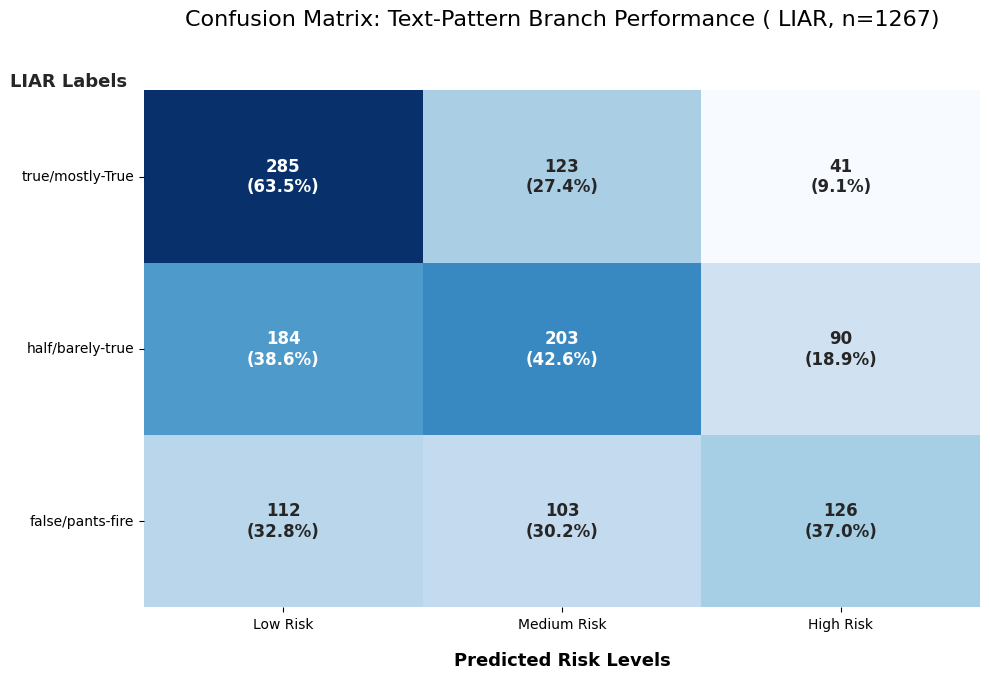

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

labels = ['true/mostly-True', 'half/barely-true', 'false/pants-fire']
predictions = ['Low Risk', 'Medium Risk', 'High Risk']
data = np.array([
    [285, 123, 41],
    [184, 203, 90],
    [112, 103, 126]
])

data_norm = data.astype('float') / data.sum(axis=1)[:, np.newaxis]
annot_text = np.array([["{}\n({:.1%})".format(val, pct) for val, pct in zip(row_val, row_pct)]
                       for row_val, row_pct in zip(data, data_norm)])

fig, ax = plt.subplots(figsize=(10, 7))
sns.set_theme(style="white", font_scale=1.1)

sns.heatmap(data,
            annot=annot_text,
            fmt="",
            cmap='Blues',
            xticklabels=predictions,
            yticklabels=labels,
            cbar=False,
            annot_kws={"size": 12, "weight": "bold"},
            ax=ax)


plt.yticks(rotation=0)
plt.xticks(rotation=0)

ax.text(-0.16, 1.0, 'LIAR Labels',
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=13,
        fontweight='bold')

plt.title('Confusion Matrix: Text-Pattern Branch Performance ( LIAR, n=1267)\n', fontsize=16, pad=30)
plt.xlabel('Predicted Risk Levels', fontsize=13, labelpad=15,fontweight='bold' )

plt.ylabel('')

plt.tight_layout()
plt.show()